# 📊 Analyse et Traitement des Opportunités Collectées

Ce notebook permet de :
- Visualiser les données collectées
- Analyser la qualité des données
- Nettoyer les données
- Préparer pour l'import PostgreSQL

## 1️⃣ Installation des dépendances

In [ ]:
# Installer les packages nécessaires
!pip install pandas matplotlib seaborn plotly numpy

## 2️⃣ Chargement des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import glob
import os

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)
sns.set_style('whitegrid')

print("✅ Bibliothèques importées avec succès")

Matplotlib is building the font cache; this may take a moment.


✅ Bibliothèques importées avec succès


In [2]:
# Trouver le fichier CSV le plus récent
csv_files = glob.glob('data/raw/opportunities_*.csv')
latest_file = max(csv_files, key=os.path.getctime)

print(f"📂 Fichier le plus récent : {latest_file}")
print(f"📅 Date de création : {datetime.fromtimestamp(os.path.getctime(latest_file))}")

# Charger les données
df = pd.read_csv(latest_file)

print(f"\n✅ Données chargées : {len(df)} opportunités")
print(f"📊 Colonnes : {list(df.columns)}")

📂 Fichier le plus récent : data/raw\opportunities_2026-08-19T14-06-35.csv
📅 Date de création : 2026-08-19 14:06:35.537289

✅ Données chargées : 110 opportunités
📊 Colonnes : ['source', 'title', 'description', 'url', 'date', 'collected_at']


## 3️⃣ Aperçu des données

In [6]:
# Afficher les premières lignes
print("🔍 Aperçu des données (5 premières lignes) :\n")
df

🔍 Aperçu des données (5 premières lignes) :



,source,title,description,url,date,collected_at
0,JSONPlaceholder (Test),sunt aut facere repellat provident occaecati excepturi optio reprehenderit,quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut u...,https://jsonplaceholder.typicode.com/posts/1,2026-08-19T14:04:52.289Z,2026-08-19T14:04:52.290Z
1,JSONPlaceholder (Test),qui est esse,est rerum tempore vitae\nsequi sint nihil reprehenderit dolor beatae ea dolores neque\nfugiat bl...,https://jsonplaceholder.typicode.com/posts/2,2026-08-19T14:04:52.290Z,2026-08-19T14:04:52.290Z
2,JSONPlaceholder (Test),ea molestias quasi exercitationem repellat qui ipsa sit aut,et iusto sed quo iure\nvoluptatem occaecati omnis eligendi aut ad\nvoluptatem doloribus vel accu...,https://jsonplaceholder.typicode.com/posts/3,2026-08-19T14:04:52.290Z,2026-08-19T14:04:52.290Z
3,JSONPlaceholder (Test),eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\nsit amet autem assumenda provident rerum culpa\nq...,https://jsonplaceholder.typicode.com/posts/4,2026-08-19T14:04:52.290Z,2026-08-19T14:04:52.290Z
4,JSONPlaceholder (Test),nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut fugiat sit autem sed est\nvoluptatem omnis possim...,https://jsonplaceholder.typicode.com/posts/5,2026-08-19T14:04:52.290Z,2026-08-19T14:04:52.290Z
...,...,...,...,...,...,...
105,PNUD Sénégal,PNUD Sénégal | Rapport Annuel 2025,Ce rapport illustre les résultats obtenus dans nos principaux domaines d’intervention : la gouve...,https://www.undp.org/fr/senegal/publications/rapport-annuel-senegal-2025,NaN,2026-08-19T14:06:12.328Z
106,PNUD Sénégal,"1,6 Millions",NaN,https://www.sn.undp.org/,NaN,2026-08-19T14:06:12.329Z
107,GIZ Sénégal,Information about our data,"The current data version is dated December 31, 2025. The data is usually available in German and...",https://www.govdata.de/dl-de/by-2-0,NaN,2026-08-19T14:06:16.246Z
108,USAID,Notice to Potential Bidders for Open solicitations for products and services for the U.S. Missio...,NaN,https://sn.usembassy.gov/author/missionsn/,NaN,2026-08-19T14:06:31.835Z


In [4]:
# Informations sur les données
print("📋 Informations sur les données :\n")
df.info()

📋 Informations sur les données :

<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   source        110 non-null    str  
 1   title         110 non-null    str  
 2   description   74 non-null     str  
 3   url           110 non-null    str  
 4   date          79 non-null     str  
 5   collected_at  110 non-null    str  
dtypes: str(6)
memory usage: 5.3 KB


In [ ]:
# Statistiques descriptives
print("📊 Statistiques descriptives :\n")
df.describe(include='all')

## 4️⃣ Analyse par source

In [7]:
# Compter les opportunités par source
source_counts = df['source'].value_counts()

print("📈 Nombre d'opportunités par source :\n")
print(source_counts)
print(f"\nTotal : {source_counts.sum()} opportunités")
print(f"Nombre de sources : {len(source_counts)}")

📈 Nombre d'opportunités par source :

source
ADEPME                                     42
Banque Mondiale                            20
BAD - Banque Africaine de Développement    20
PNUD Sénégal                                9
DER Sénégal                                 6
JSONPlaceholder (Test)                      5
ARCOP (ex-ARMP) Sénégal                     4
USAID                                       2
Union Européenne                            1
GIZ Sénégal                                 1
Name: count, dtype: int64

Total : 110 opportunités
Nombre de sources : 10


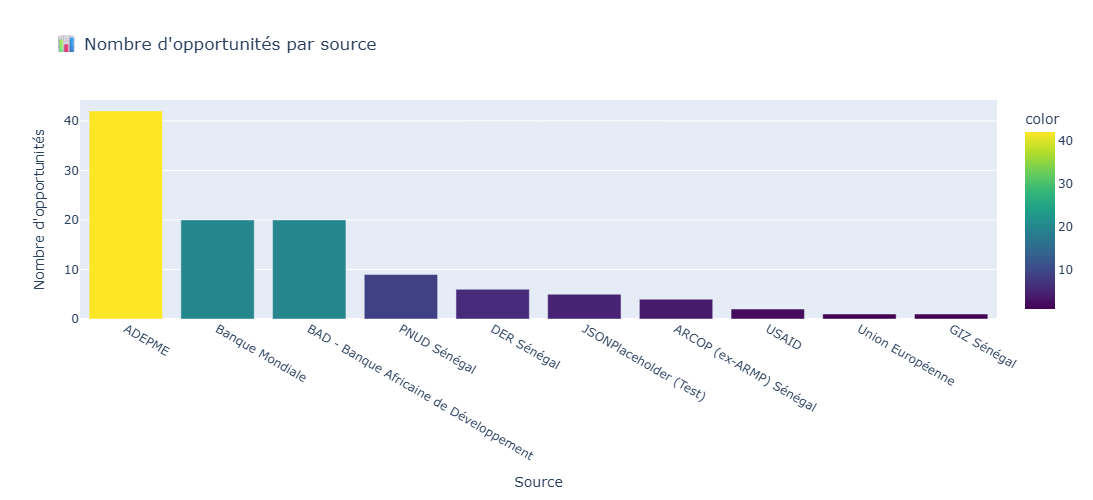

In [8]:
# Graphique en barres - Opportunités par source
fig = px.bar(
    x=source_counts.index,
    y=source_counts.values,
    title='📊 Nombre d\'opportunités par source',
    labels={'x': 'Source', 'y': 'Nombre d\'opportunités'},
    color=source_counts.values,
    color_continuous_scale='Viridis'
)
fig.update_layout(showlegend=False, height=500)
fig.show()

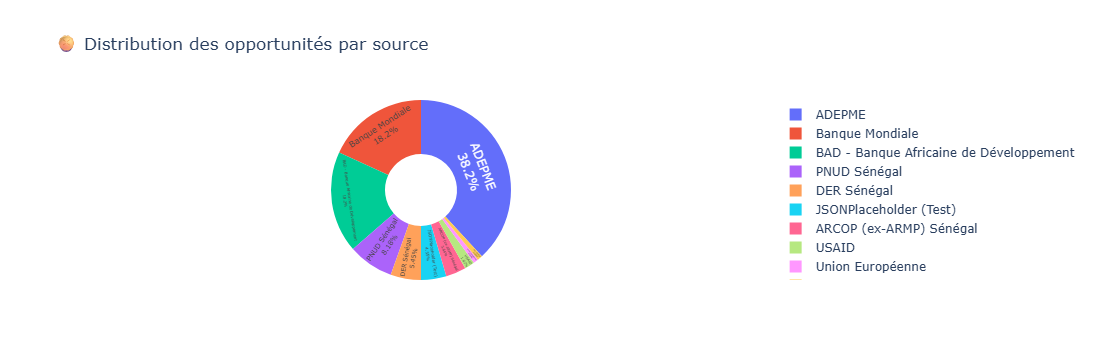

In [9]:
# Graphique circulaire - Distribution par source
fig = px.pie(
    values=source_counts.values,
    names=source_counts.index,
    title='🥧 Distribution des opportunités par source',
    hole=0.4
)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

## 5️⃣ Analyse de la qualité des données

In [10]:
# Valeurs manquantes
print("🔍 Valeurs manquantes par colonne :\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Nombre': missing,
    'Pourcentage': missing_pct.round(2)
})
print(missing_df[missing_df['Nombre'] > 0])

🔍 Valeurs manquantes par colonne :

             Nombre  Pourcentage
description      36        32.73
date             31        28.18


📏 Statistiques sur la longueur des titres :
count    110.00000
mean      47.90000
std       55.01742
min        7.00000
25%       12.25000
50%       25.00000
75%       54.00000
max      200.00000
Name: title_length, dtype: float64


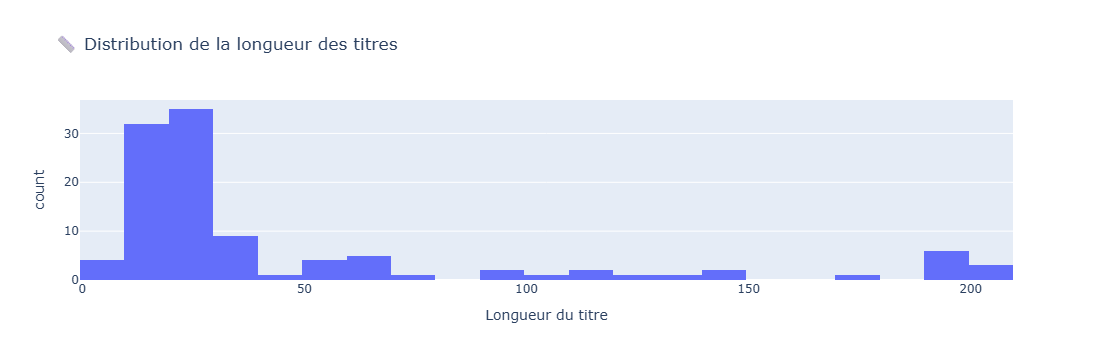

In [11]:
# Longueur des titres
df['title_length'] = df['title'].fillna('').str.len()

print("📏 Statistiques sur la longueur des titres :")
print(df['title_length'].describe())

# Histogramme
fig = px.histogram(
    df,
    x='title_length',
    title='📏 Distribution de la longueur des titres',
    nbins=30,
    labels={'title_length': 'Longueur du titre'}
)
fig.show()

In [12]:
# Longueur des descriptions
df['description_length'] = df['description'].fillna('').str.len()

print("📏 Statistiques sur la longueur des descriptions :")
print(df['description_length'].describe())

# Opportunités avec description vide ou très courte
short_desc = df[df['description_length'] < 50]
print(f"\n⚠️ {len(short_desc)} opportunités avec description < 50 caractères")

📏 Statistiques sur la longueur des descriptions :
count    110.000000
mean      58.245455
std      102.524840
min        0.000000
25%        0.000000
50%       10.000000
75%       71.000000
max      500.000000
Name: description_length, dtype: float64

⚠️ 69 opportunités avec description < 50 caractères


In [13]:
# Vérifier les URLs
df['url_valid'] = df['url'].str.startswith('http')

print("🔗 Validation des URLs :")
print(f"URLs valides : {df['url_valid'].sum()}")
print(f"URLs invalides : {(~df['url_valid']).sum()}")

if (~df['url_valid']).sum() > 0:
    print("\n⚠️ URLs invalides :")
    print(df[~df['url_valid']][['source', 'title', 'url']].head())

🔗 Validation des URLs :
URLs valides : 110
URLs invalides : 0


## 6️⃣ Nettoyage des données

In [14]:
# Créer une copie pour le nettoyage
df_clean = df.copy()

print("🧹 Début du nettoyage des données...\n")

# 1. Supprimer les opportunités de test
before = len(df_clean)
df_clean = df_clean[~df_clean['source'].str.contains('Test', case=False, na=False)]
print(f"✅ {before - len(df_clean)} opportunités de test supprimées")

# 2. Supprimer les doublons exacts
before = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['title', 'url'], keep='first')
print(f"✅ {before - len(df_clean)} doublons exacts supprimés")

# 3. Nettoyer les titres
df_clean['title'] = df_clean['title'].str.strip()
df_clean['title'] = df_clean['title'].str.replace('\s+', ' ', regex=True)
print(f"✅ Titres nettoyés")

# 4. Nettoyer les descriptions
df_clean['description'] = df_clean['description'].str.strip()
df_clean['description'] = df_clean['description'].str.replace('\s+', ' ', regex=True)
print(f"✅ Descriptions nettoyées")

# 5. Supprimer les opportunités avec titre trop court
before = len(df_clean)
df_clean = df_clean[df_clean['title'].str.len() >= 10]
print(f"✅ {before - len(df_clean)} opportunités avec titre < 10 caractères supprimées")

# 6. Convertir les dates
df_clean['collected_at'] = pd.to_datetime(df_clean['collected_at'], errors='coerce')
print(f"✅ Dates converties")

print(f"\n📊 Résultat final : {len(df_clean)} opportunités nettoyées (depuis {len(df)} au départ)")

🧹 Début du nettoyage des données...

✅ 5 opportunités de test supprimées
✅ 15 doublons exacts supprimés
✅ Titres nettoyés
✅ Descriptions nettoyées
✅ 3 opportunités avec titre < 10 caractères supprimées
✅ Dates converties

📊 Résultat final : 87 opportunités nettoyées (depuis 110 au départ)


In [15]:
# Aperçu des données nettoyées
print("🔍 Aperçu des données nettoyées :\n")
df_clean[['source', 'title', 'url']].head(10)

🔍 Aperçu des données nettoyées :



,source,title,url
5,DER Sénégal,Notre mission,https://www.der.sn/la-der-fj/
6,DER Sénégal,PAVIE: AVIS À MANIFESTATION D’INTÉRÊT,https://www.der.sn/pavie-avis-a-manifestation-dinteret/
7,DER Sénégal,PAVIE: APPEL À MANIFESTATION D’INTÉRÊT,https://www.der.sn/pavie-appel-a-manifestation-dinteret-3/
8,DER Sénégal,PAVIE: APPEL À MANIFESTATION D’INTÉRÊT,https://www.der.sn/pavie-appel-a-manifestation-dinteret-2/
9,DER Sénégal,PAVIE: APPEL À MANIFESTATION D’INTÉRÊT,https://www.der.sn/pavie-appel-a-manifestation-dinteret/
10,DER Sénégal,𝐏𝐀𝐀𝐈𝐂𝐄: 𝐀𝐯𝐢𝐬 𝐝’𝐀𝐩𝐩𝐞𝐥 𝐝’𝐎𝐟𝐟𝐫𝐞𝐬,https://www.der.sn/%f0%9d%90%8f%f0%9d%90%80%f0%9d%90%80%f0%9d%90%88%f0%9d%90%82%f0%9d%90%84-%f0%...
11,ARCOP (ex-ARMP) Sénégal,PLUSIEURS ANNÉES SANS EXCLUSION : L’ARCOP prononce une sanction rare contre NDIAPANDAL SERVICES,https://www.achatspublics.sn/
12,ARCOP (ex-ARMP) Sénégal,PLUSIEURS ANNÉES SANS EXCLUSION : L’ARCOP prononce une sanction rare contre NDIAPANDAL SERVICES,https://arcop.sn/2026/08/14/plusieurs-annees-sans-exclusion-larcop-prononce-une-sanction-rare-co...
13,ARCOP (ex-ARMP) Sénégal,ACCES DES PME A LA COMMANDE PUBLIQUE : La Caisse des Marchés et l’ARCOP explorent de nouvelles s...,https://arcop.sn/2026/08/14/acces-des-pme-a-la-commande-publique-la-caisse-des-marches-et-larcop...
14,ARCOP (ex-ARMP) Sénégal,"PREFERENCES, RESERVATIONS, OFFRES SPONTANEES, PPP : L’ARCOP appelle le secteur privé national à ...",https://arcop.sn/2026/08/12/preferences-reservations-offres-spontanees-ppp-larcop-appelle-le-sec...


## 7️⃣ Analyse des sources sénégalaises

In [16]:
# Filtrer les sources sénégalaises
sources_senegal = ['DER Sénégal', 'ARCOP (ex-ARMP) Sénégal', 'ADEPME']
df_senegal = df_clean[df_clean['source'].isin(sources_senegal)]

print(f"🇸🇳 Opportunités sénégalaises : {len(df_senegal)}")
print(f"\nPar source :")
print(df_senegal['source'].value_counts())

# Exemples d'opportunités sénégalaises
print("\n📋 Exemples d'opportunités sénégalaises :\n")
for _, row in df_senegal.head(5).iterrows():
    print(f"Source: {row['source']}")
    print(f"Titre: {row['title'][:80]}...")
    print(f"URL: {row['url']}")
    print("-" * 80)

🇸🇳 Opportunités sénégalaises : 40

Par source :
source
ADEPME                     30
DER Sénégal                 6
ARCOP (ex-ARMP) Sénégal     4
Name: count, dtype: int64

📋 Exemples d'opportunités sénégalaises :

Source: DER Sénégal
Titre: Notre mission...
URL: https://www.der.sn/la-der-fj/
--------------------------------------------------------------------------------
Source: DER Sénégal
Titre: PAVIE: AVIS À MANIFESTATION D’INTÉRÊT...
URL: https://www.der.sn/pavie-avis-a-manifestation-dinteret/
--------------------------------------------------------------------------------
Source: DER Sénégal
Titre: PAVIE: APPEL À MANIFESTATION D’INTÉRÊT...
URL: https://www.der.sn/pavie-appel-a-manifestation-dinteret-3/
--------------------------------------------------------------------------------
Source: DER Sénégal
Titre: PAVIE: APPEL À MANIFESTATION D’INTÉRÊT...
URL: https://www.der.sn/pavie-appel-a-manifestation-dinteret-2/
---------------------------------------------------------------------

## 8️⃣ Sauvegarde des données nettoyées

In [17]:
# Créer le dossier cleaned s'il n'existe pas
os.makedirs('data/cleaned', exist_ok=True)

# Sauvegarder avec timestamp
timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
output_file = f'data/cleaned/opportunities_clean_{timestamp}.csv'

# Sélectionner les colonnes pour PostgreSQL
df_export = df_clean[['source', 'title', 'description', 'url', 'date', 'collected_at']].copy()

# Sauvegarder
df_export.to_csv(output_file, index=False, encoding='utf-8')

print(f"✅ Données nettoyées sauvegardées : {output_file}")
print(f"📊 {len(df_export)} opportunités prêtes pour PostgreSQL")

✅ Données nettoyées sauvegardées : data/cleaned/opportunities_clean_2026-08-19_23-20-34.csv
📊 87 opportunités prêtes pour PostgreSQL


## 9️⃣ Rapport final

In [18]:
print("="*80)
print("📊 RAPPORT FINAL DE COLLECTE")
print("="*80)

print(f"\n📅 Date de collecte : {df_clean['collected_at'].max()}")
print(f"\n📈 Statistiques globales :")
print(f"  - Opportunités brutes collectées : {len(df)}")
print(f"  - Opportunités après nettoyage : {len(df_clean)}")
print(f"  - Taux de rétention : {(len(df_clean)/len(df)*100):.1f}%")

print(f"\n🌍 Par type de source :")
senegal_count = len(df_clean[df_clean['source'].isin(sources_senegal)])
international_count = len(df_clean[~df_clean['source'].isin(sources_senegal)])
print(f"  - Sources sénégalaises : {senegal_count} ({senegal_count/len(df_clean)*100:.1f}%)")
print(f"  - Sources internationales : {international_count} ({international_count/len(df_clean)*100:.1f}%)")

print(f"\n📋 Top 5 des sources :")
for source, count in df_clean['source'].value_counts().head().items():
    print(f"  - {source}: {count}")

print(f"\n✅ Prêt pour l'import PostgreSQL !")
print(f"📂 Fichier : {output_file}")
print("="*80)

📊 RAPPORT FINAL DE COLLECTE

📅 Date de collecte : 2026-08-19 14:06:31.836000+00:00

📈 Statistiques globales :
  - Opportunités brutes collectées : 110
  - Opportunités après nettoyage : 87
  - Taux de rétention : 79.1%

🌍 Par type de source :
  - Sources sénégalaises : 40 (46.0%)
  - Sources internationales : 47 (54.0%)

📋 Top 5 des sources :
  - ADEPME: 30
  - Banque Mondiale: 20
  - BAD - Banque Africaine de Développement: 20
  - DER Sénégal: 6
  - ARCOP (ex-ARMP) Sénégal: 4

✅ Prêt pour l'import PostgreSQL !
📂 Fichier : data/cleaned/opportunities_clean_2026-08-19_23-20-34.csv
